# Учимся работе с данными - от загрузки до моделирования

Загружено 569 строк, 33 колонок
Признаков: 30
Классы: {0: 357, 1: 212}
Пропусков: 0
Статистика по признакам:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.372583
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,0.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000



Распределение классов:
diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


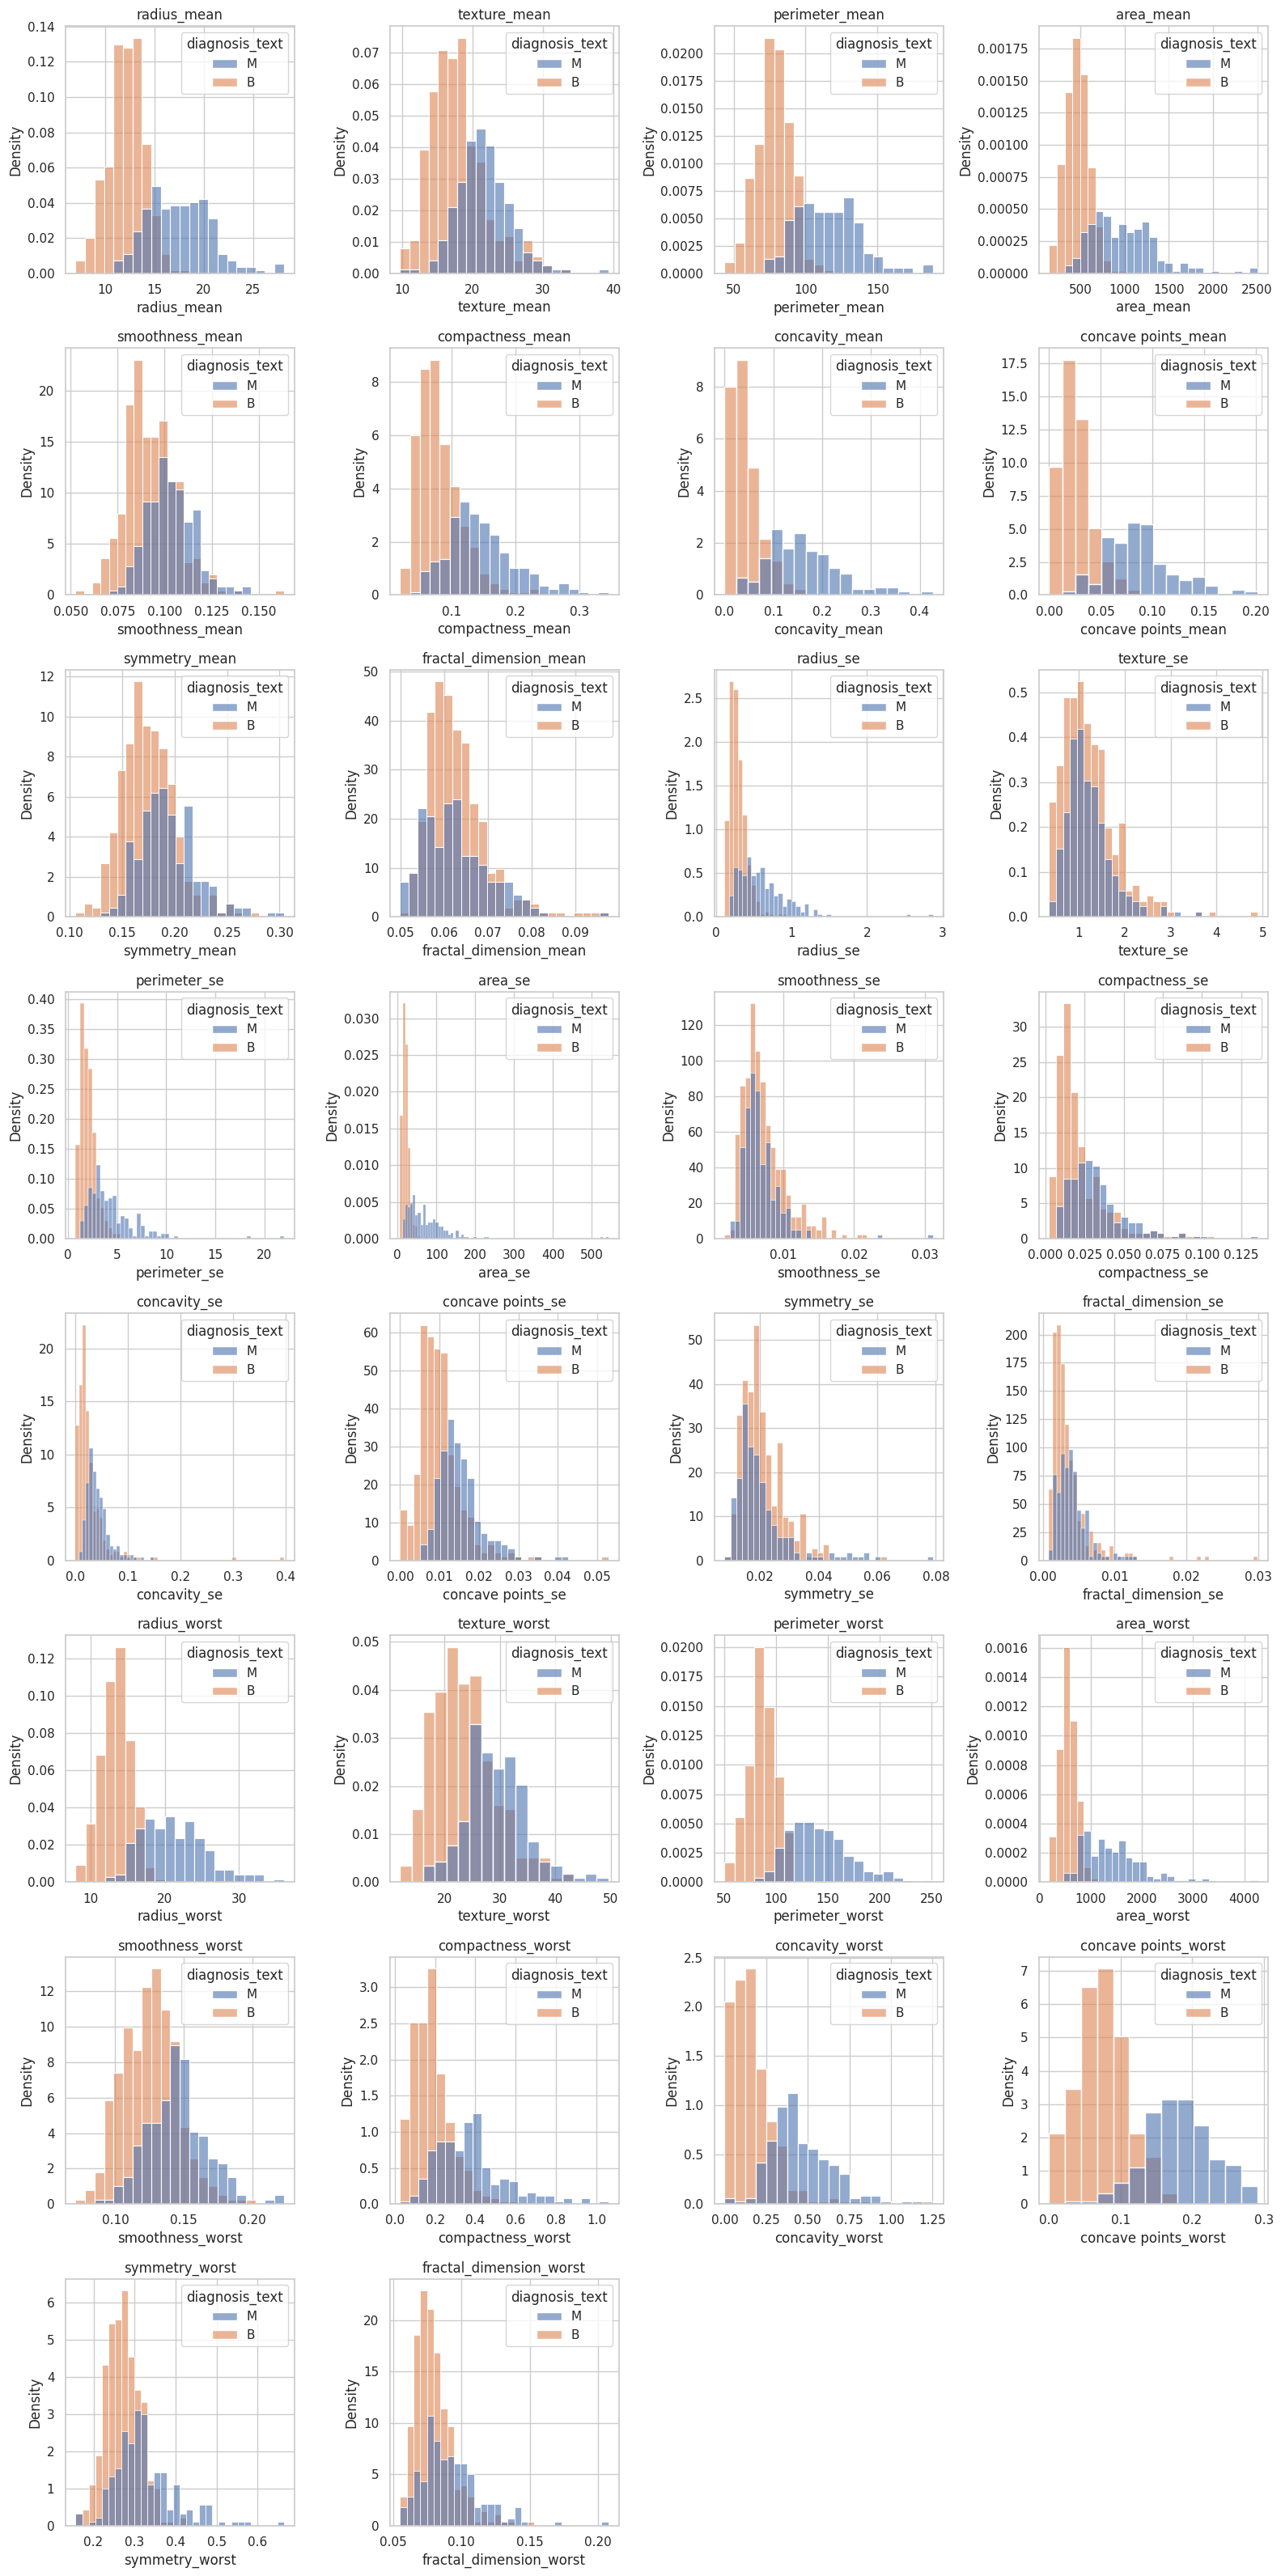

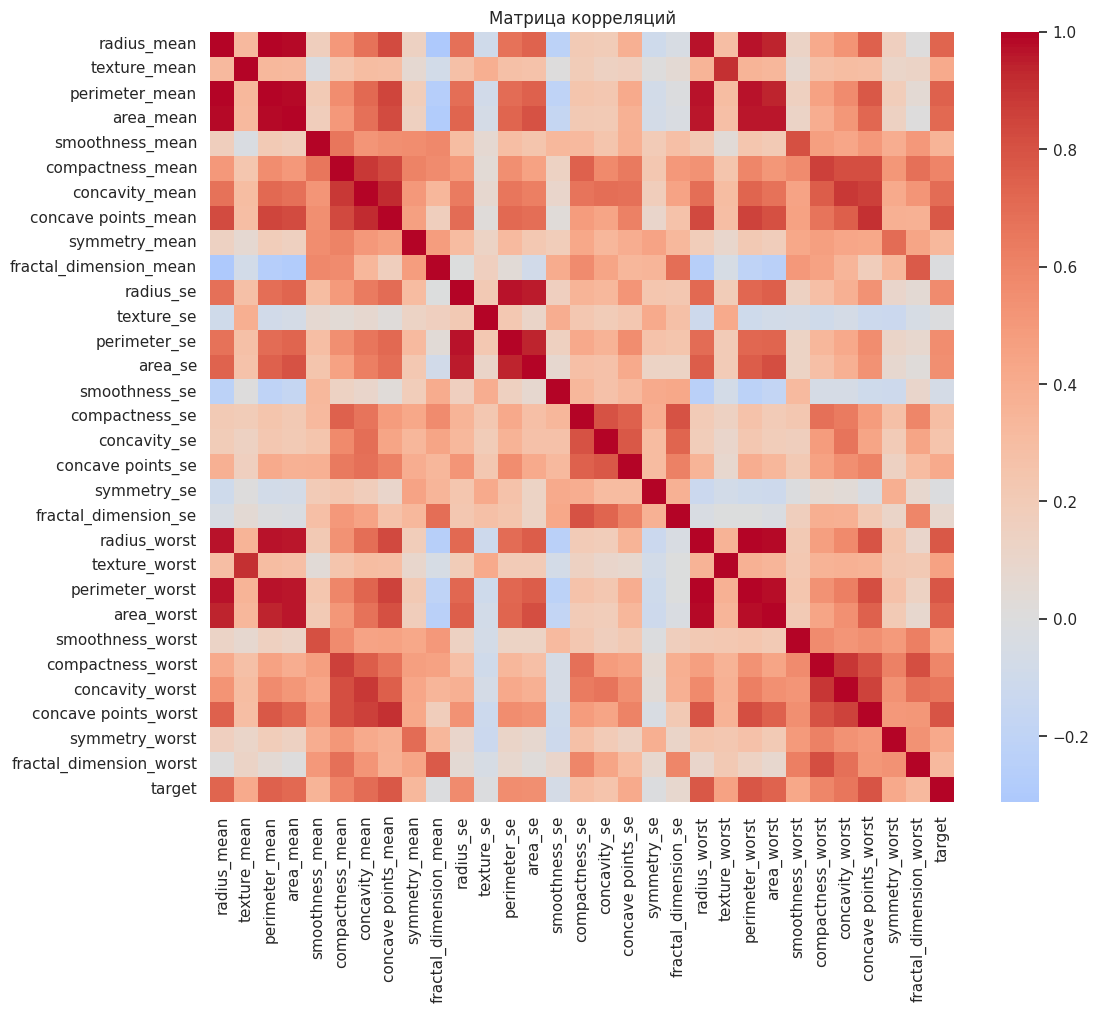

Сильные корреляции: [('radius_mean', 'perimeter_mean', np.float64(0.9978552814938109)), ('radius_mean', 'area_mean', np.float64(0.9873571700566127)), ('radius_mean', 'radius_worst', np.float64(0.9695389726112055)), ('radius_mean', 'perimeter_worst', np.float64(0.9651365139559871)), ('radius_mean', 'area_worst', np.float64(0.9410824595860461))]


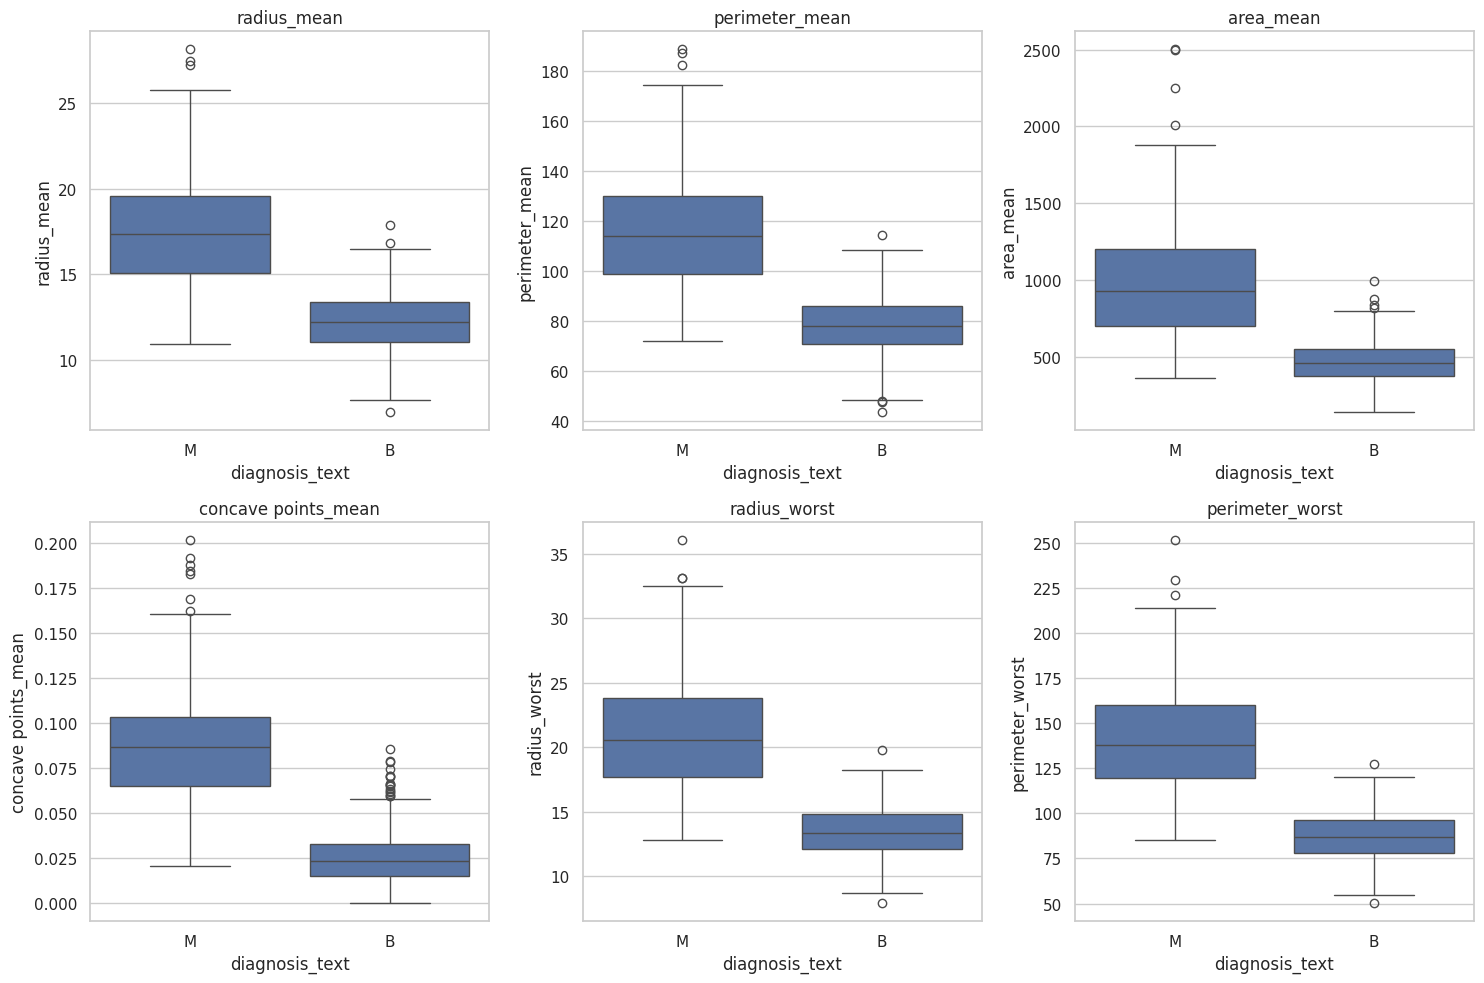

Train: (398, 30), Test: (171, 30)
Пропусков после обработки: 0
kNN default: {'accuracy': 0.9649122807017544, 'precision': 1.0, 'recall': 0.90625, 'f1': 0.9508196721311475}
Лучший k: 5, CV accuracy: 0.9697


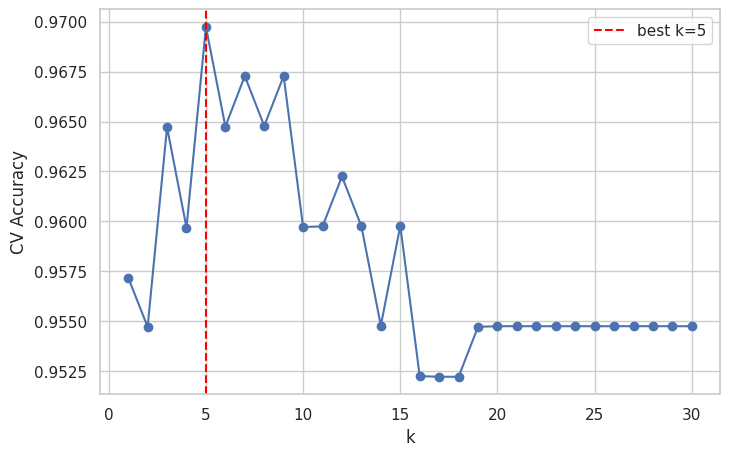

kNN best: {'accuracy': 0.9649122807017544, 'precision': 1.0, 'recall': 0.90625, 'f1': 0.9508196721311475}


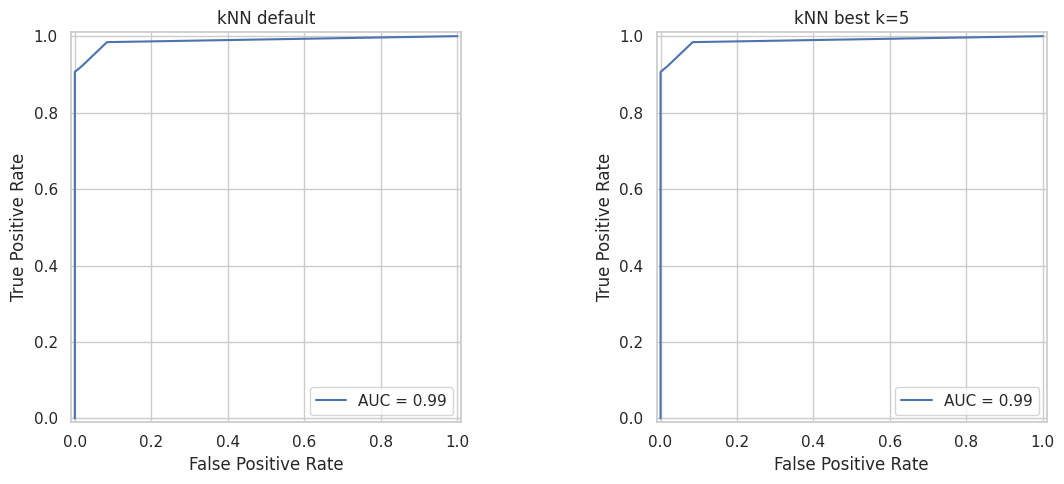

Удаляем 13 сильно коррелированных признаков
Оставшихся признаков: 17
Logistic Regression: {'accuracy': 0.9766081871345029, 'precision': 1.0, 'recall': 0.9375, 'f1': 0.967741935483871}
Logistic Regression CV: {'accuracy': 0.9707602339181286, 'precision': 1.0, 'recall': 0.921875, 'f1': 0.959349593495935}
Лучший C: 0.359


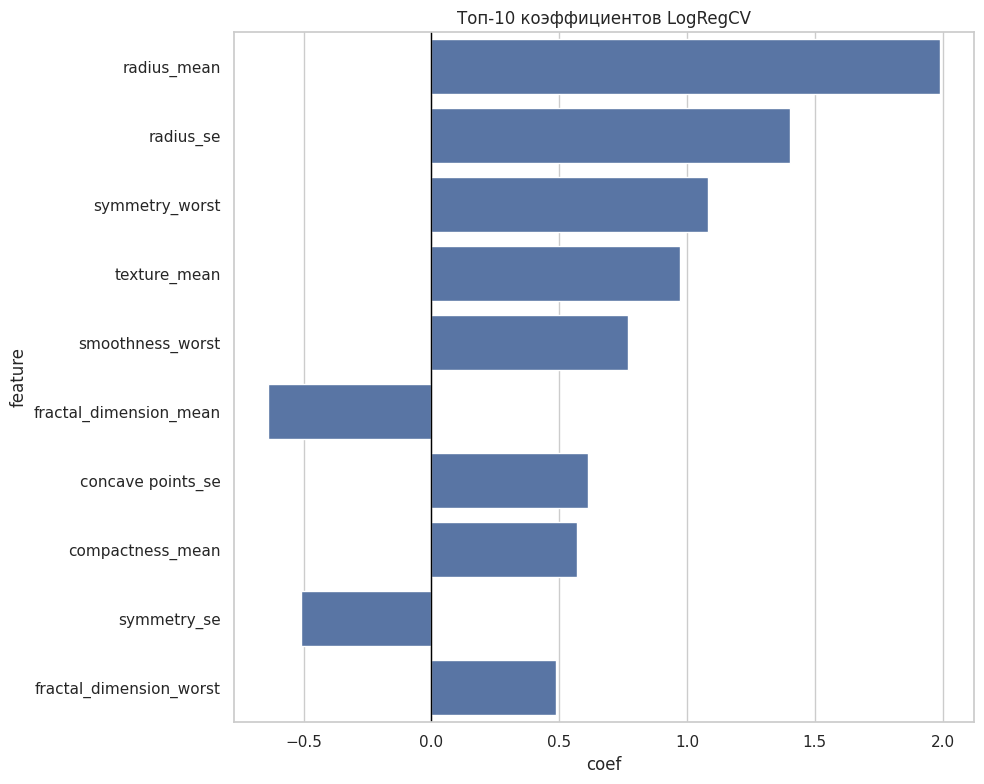

,kNN_default,kNN_best,LogReg,LogRegCV
accuracy,0.964900,0.964900,0.976600,0.970800
precision,1.000000,1.000000,1.000000,1.000000
recall,0.906200,0.906200,0.937500,0.921900
f1,0.950800,0.950800,0.967700,0.959300


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            roc_curve, auc, classification_report, RocCurveDisplay)
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Загрузка данных
df = pd.read_csv("data.csv")
print(f"Загружено {df.shape[0]} строк, {df.shape[1]} колонок")
df.head()

# Целевая переменная: M=1 (злокачественная), B=0 (доброкачественная)
df['target'] = df['diagnosis'].map({'M': 1, 'B': 0})
df['diagnosis_text'] = df['diagnosis']

# Числовые признаки (исключаем id и target)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['id', 'target', 'Unnamed: 32']]

X = df[numeric_cols].copy()
y = df['target']

print(f"Признаков: {len(numeric_cols)}")
print(f"Классы: {y.value_counts().to_dict()}")
print(f"Пропусков: {X.isnull().sum().sum()}")

print("Статистика по признакам:")
display(df[numeric_cols + ['target']].describe())

print("\nРаспределение классов:")
print(df['diagnosis'].value_counts(normalize=True))

# Только признаки с данными в обеих группах
safe_cols = [col for col in numeric_cols
             if df[df['diagnosis_text']=='B'][col].notna().any()
             and df[df['diagnosis_text']=='M'][col].notna().any()]

n_cols, n_rows = 4, (len(safe_cols) + 3) // 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.ravel()

for i, col in enumerate(safe_cols):
    if i < len(axes):
        sns.histplot(data=df, x=col, hue='diagnosis_text',
                    stat="density", ax=axes[i], alpha=0.6)
        axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
corr = df[numeric_cols + ['target']].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Матрица корреляций')
plt.show()

# Сильные корреляции (>0.85)
upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_corr = [(c1, c2, corr.loc[c1,c2]) for c1 in corr.index for c2 in corr.columns
              if c1 != c2 and abs(corr.loc[c1,c2]) > 0.85]
print("Сильные корреляции:", strong_corr[:5])

top_features = ['radius_mean', 'perimeter_mean', 'area_mean', 'concave points_mean',
                'radius_worst', 'perimeter_worst']

n_cols, n_rows = 3, (len(top_features) + 2) // 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.ravel()

for i, feat in enumerate(top_features):
    if i < len(axes):
        sns.boxplot(data=df, x='diagnosis_text', y=feat, ax=axes[i])
        axes[i].set_title(feat)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Пайплайн: заполнение пропусков + стандартизация
knn_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_train_scaled = knn_pipeline.fit_transform(X_train, y_train)
X_test_scaled = knn_pipeline.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")
print("Пропусков после обработки:", pd.DataFrame(X_train_scaled).isnull().sum().sum())

knn_default = KNeighborsClassifier(n_neighbors=5)
knn_default.fit(X_train_scaled, y_train)

y_pred_def = knn_default.predict(X_test_scaled)
y_proba_def = knn_default.predict_proba(X_test_scaled)[:, 1]

metrics_def = {
    'accuracy': accuracy_score(y_test, y_pred_def),
    'precision': precision_score(y_test, y_pred_def),
    'recall': recall_score(y_test, y_pred_def),
    'f1': f1_score(y_test, y_pred_def)
}
print("kNN default:", metrics_def)

k_range = range(1, 31)
cv_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k),
                           X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
             for k in k_range]

best_k = k_range[np.argmax(cv_scores)]
print(f"Лучший k: {best_k}, CV accuracy: {max(cv_scores):.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, cv_scores, 'o-')
plt.axvline(best_k, color='red', linestyle='--', label=f'best k={best_k}')
plt.xlabel('k'); plt.ylabel('CV Accuracy'); plt.legend(); plt.grid(True)
plt.show()

# Лучшая kNN модель
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)

y_pred_best = knn_best.predict(X_test_scaled)
y_proba_best = knn_best.predict_proba(X_test_scaled)[:, 1]

metrics_best = {
    'accuracy': accuracy_score(y_test, y_pred_best),
    'precision': precision_score(y_test, y_pred_best),
    'recall': recall_score(y_test, y_pred_best),
    'f1': f1_score(y_test, y_pred_best)
}
print("kNN best:", metrics_best)


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# kNN default
fpr_def, tpr_def, _ = roc_curve(y_test, y_proba_def)
RocCurveDisplay(fpr=fpr_def, tpr=tpr_def, roc_auc=auc(fpr_def, tpr_def)).plot(ax=ax[0])
ax[0].set_title('kNN default')

# kNN best
fpr_best, tpr_best, _ = roc_curve(y_test, y_proba_best)
RocCurveDisplay(fpr=fpr_best, tpr=tpr_best, roc_auc=auc(fpr_best, tpr_best)).plot(ax=ax[1])
ax[1].set_title(f'kNN best k={best_k}')

plt.tight_layout()
plt.show()

corr_matrix = pd.DataFrame(X_train_scaled).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

print(f"Удаляем {len(to_drop)} сильно коррелированных признаков")
X_red = X.drop(columns=[numeric_cols[i] for i in to_drop])
print(f"Оставшихся признаков: {X_red.shape[1]}")

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_red, y, test_size=0.3, random_state=42, stratify=y
)

lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
X_train_r_scaled = lr_pipeline.fit_transform(X_train_r, y_train_r)
X_test_r_scaled = lr_pipeline.transform(X_test_r)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_r_scaled, y_train_r)

y_pred_lr = logreg.predict(X_test_r_scaled)
y_proba_lr = logreg.predict_proba(X_test_r_scaled)[:, 1]

metrics_lr = {
    'accuracy': accuracy_score(y_test_r, y_pred_lr),
    'precision': precision_score(y_test_r, y_pred_lr),
    'recall': recall_score(y_test_r, y_pred_lr),
    'f1': f1_score(y_test_r, y_pred_lr)
}
print("Logistic Regression:", metrics_lr)

logreg_cv = LogisticRegressionCV(
    Cs=10, cv=5, penalty='l2', scoring='accuracy',
    max_iter=1000, random_state=42, n_jobs=-1
)
logreg_cv.fit(X_train_r_scaled, y_train_r)

y_pred_lrcv = logreg_cv.predict(X_test_r_scaled)
metrics_lrcv = {
    'accuracy': accuracy_score(y_test_r, y_pred_lrcv),
    'precision': precision_score(y_test_r, y_pred_lrcv),
    'recall': recall_score(y_test_r, y_pred_lrcv),
    'f1': f1_score(y_test_r, y_pred_lrcv)
}
print("Logistic Regression CV:", metrics_lrcv)
print(f"Лучший C: {logreg_cv.C_[0]:.3f}")

# Коэффициенты
coef_df = pd.DataFrame({
    'feature': X_red.columns,
    'coef': logreg_cv.coef_[0]
}).sort_values('coef', key=abs, ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=coef_df.head(10), x='coef', y='feature')
plt.axvline(0, color='black', lw=1)
plt.title('Топ-10 коэффициентов LogRegCV')
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    'kNN_default': list(metrics_def.values()),
    'kNN_best': list(metrics_best.values()),
    'LogReg': list(metrics_lr.values()),
    'LogRegCV': list(metrics_lrcv.values())
}, index=['accuracy', 'precision', 'recall', 'f1'])

comparison.round(4).style.highlight_max(axis=1, color='lightgreen')

